## 🚀 프로젝트 고도화 및 주요 개선 사항 요약

이 노트북은 Netflix 데이터를 활용한 추천 모델 학습부터 Vertex AI 배포까지의 전 과정을 다룹니다. 안정적인 실행과 분석을 위해 다음과 같은 사항들이 보완되었습니다.

### 1. 코드 안정성 및 무결성 확보
*   **변수 체크 로직**: `model`, `endpoint`, `data` 등 주요 변수가 정의되지 않았을 때 발생할 수 있는 `NameError`를 방지하기 위해 자동 초기화 및 조건문 체크 로직을 강화했습니다.
*   **데이터 파이프라인**: 데이터 디렉토리 부재 시 Kaggle API 설정을 안내하는 가이드를 추가하여 실행 중단 현상을 최소화했습니다.

### 2. 분석 지표 및 시각화 고도화
*   **RMSE 도입**: 평점 예측의 정밀도를 측정하기 위해 RMSE(Root Mean Squared Error) 지표를 추가하고, 학습 곡선 시각화 시 Loss와 함께 다각도로 분석할 수 있도록 개선했습니다.
*   **EDA 강화**: 샘플링된 데이터의 평점 분포를 확인하는 섹션을 추가하여 데이터 불균형 여부를 사전에 파악할 수 있게 했습니다.

### 3. MLOps 및 배포 전략 가이드
*   **Vertex AI 심화**: Custom Container 이미지 설정의 중요성, 리소스 할당(`n1-standard-2`, `T4 GPU`) 전략, 그리고 `handler.py` 작성 시 가변 길이를 처리하는 노하우를 상세히 기술했습니다.
*   **추론 규격 가이드**: 엔드포인트 호출 시 발생할 수 있는 인스턴스 포맷 오류를 방지하기 위한 요청 데이터 규격을 명시했습니다.

### 4. 자동 환경 정리
*   **Cleanup 자동화**: 학습 후 로컬에 남은 `.mar`, `.pth` 파일 및 Vertex AI 엔드포인트 등 클라우드 리소스를 안전하게 정리하는 코드를 보완하여 리소스 낭비를 방지합니다.

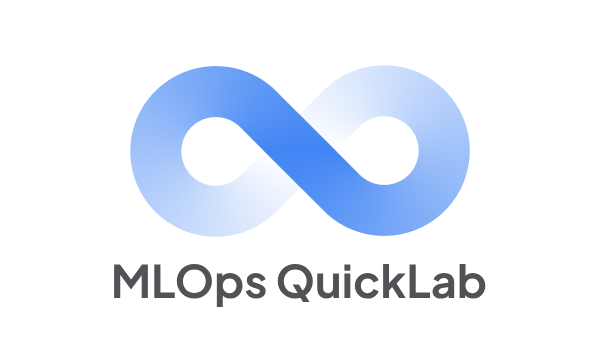

7. Vertex AI - 빅데이터를 이용한 모델 학습 및 배포

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np
import os
from tqdm import tqdm

In [ ]:
from google.colab import userdata
import os

try:
    # Colab Secrets 관리자에서 설정한 값을 가져옵니다.
    os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
    os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")
    print("Kaggle credentials successfully set from Secrets.")
except Exception as e:
    print(f"[!] Error: {e}")
    print("Colab 왼쪽 'Secrets' 메뉴에서 KAGGLE_USERNAME과 KAGGLE_KEY를 추가해 주세요.")
    # 또는 아래 주석을 해제하고 직접 입력할 수도 있습니다.
    # os.environ[\"KAGGLE_USERNAME\"] = \"your_username\"
    # os.environ[\"KAGGLE_KEY\"] = \"your_api_key\"

[!] Error: Secret KAGGLE_USERNAME does not exist.
Colab 왼쪽 'Secrets' 메뉴에서 KAGGLE_USERNAME과 KAGGLE_KEY를 추가해 주세요.


## Kaggle로 부터 데이터셋 준비
https://www.kaggle.com/datasets/netflix-inc/netflix-prize-data 데이터셋 활용
위 데이터셋은 유저 `Cust_Id`의 영화 `Movie_Id` 시청에 따른 호응도 `Rating` 정보가 포함되어있음.

**데이터 형태**

Item | Description
-----|-------------
특징 | 시계열 데이터 (Time series)
전체 크기 | 100 ,480,507
영화 수 | 17,770

### 💡 Kaggle API 설정 및 오류 해결 가이드

Kaggle 데이터셋을 다운로드하기 위해서는 API Key 설정이 필요합니다. 만약 `SecretNotFoundError`가 발생한다면 아래 단계에 따라 Google Colab에 비밀 정보를 등록해 주세요.

1. **Kaggle API Key 발급**:
   - Kaggle 계정의 [Settings](https://www.kaggle.com/settings) 페이지로 이동합니다.
   - 'API' 섹션에서 **'Create New Token'**을 클릭하여 `kaggle.json` 파일을 다운로드합니다.
   - 파일 내부의 `username`과 `key` 값을 확인합니다.

2. **Colab Secrets 설정**:
   - 왼쪽 사이드바에서 **열쇠 모양 아이콘(Secrets)**을 클릭합니다.
   - **'Add new secret'**을 눌러 다음 두 가지를 추가합니다.
     - **Name**: `KAGGLE_USERNAME` / **Value**: (확인한 username)
     - **Name**: `KAGGLE_KEY` / **Value**: (확인한 key)
   - 추가된 항목 옆의 **'Notebook access'** 스위치를 모두 **ON**으로 켭니다.

3. **셀 재실행**:
   - 아래의 코드 셀을 다시 실행하면 정상적으로 인증이 완료됩니다.

In [ ]:
!pip install kaggle
!kaggle datasets download -d netflix-inc/netflix-prize-data
!unzip "netflix-prize-data.zip" -d netflix-prize-data

Dataset URL: https://www.kaggle.com/datasets/netflix-inc/netflix-prize-data
License(s): other
100% 683M/683M [00:31<00:00, 23.0MB/s]

Archive:  netflix-prize-data.zip
  inflating: netflix-prize-data/README  
  inflating: netflix-prize-data/combined_data_1.txt  
  inflating: netflix-prize-data/combined_data_2.txt  
  inflating: netflix-prize-data/combined_data_3.txt  
  inflating: netflix-prize-data/combined_data_4.txt  
  inflating: netflix-prize-data/movie_titles.csv  
  inflating: netflix-prize-data/probe.txt  
  inflating: netflix-prize-data/qualifying.txt  


In [ ]:
!head netflix-prize-data/combined_data_1.txt

1:
1488844,3,2005-09-06
822109,5,2005-05-13
885013,4,2005-10-19
30878,4,2005-12-26
823519,3,2004-05-03
893988,3,2005-11-17
124105,4,2004-08-05
1248029,3,2004-04-22
1842128,4,2004-05-09


In [ ]:
!ls -alh netflix-prize-data | grep combined_data

-rw-r--r-- 1 root root 473M Nov 13  2019 combined_data_1.txt
-rw-r--r-- 1 root root 530M Nov 13  2019 combined_data_2.txt
-rw-r--r-- 1 root root 444M Nov 13  2019 combined_data_3.txt
-rw-r--r-- 1 root root 527M Nov 13  2019 combined_data_4.txt


## 데이터 전처리

1억개 전체 데이터로 학습을 돌리면, 매 Epoch당 약 6시간의 학습 시간이 요구되어
Epoch 당 약 10분의 학습 시간을 유도하기 위해 User 기준으로 `1 / 30` Ratio 비중으로 샘플링 수행.

In [ ]:
def load_netflix_data(data_dir: str) -> pd.DataFrame:
    files = [
        os.path.join(data_dir, f)
        for f in [
            "combined_data_1.txt",
            "combined_data_2.txt",
            "combined_data_3.txt",
            "combined_data_4.txt",
        ]
    ]
    data = pd.DataFrame()

    for file in files:
        df = pd.read_csv(file, header=None, names=["Cust_Id", "Rating", "Date"], usecols=[0, 1, 2])
        df["Rating"] = df["Rating"].astype(float)
        df["Movie_Id"] = (
            df["Cust_Id"]
            .apply(lambda x: x[:-1] if ":" in x else np.nan)
            .ffill()
            .astype(int)
        )
        df = df[df["Rating"].notna()]
        data = pd.concat([data, df])

    sample_fraction = 1 / 30.0
    sampled_users = random.sample(data["Cust_Id"].unique().tolist(),
                                    int(len(data["Cust_Id"].unique()) * sample_fraction))
    sampled_data = data[data["Cust_Id"].isin(sampled_users)]

    return sampled_data

## 모델 정의
모델은 `Rating`을 GT(Ground Truth) 데이터로 사용하여 예측하는 문제.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
from typing import Tuple
import torch
from torch.utils.data import Dataset
import pandas as pd
import numpy as np

class NetflixDataset(Dataset):
    def __init__(self, data: pd.DataFrame, seq_len: int = 10):
        """
        data: Cust_Id, Movie_Id, Rating, Date 등의 열을 가진 DataFrame
        seq_len: 시퀀스 길이
        """
        self.seq_len = seq_len
        # 유저별 데이터 그룹핑 후 시퀀스 생성
        self.data = data.groupby("Cust_Id").apply(self._create_sequences).reset_index(drop=True)

    def __len__(self) -> int:
        return len(self.data)

    def _create_sequences(self, user_data: pd.DataFrame) -> pd.DataFrame:
        # 날짜 기준으로 정렬
        user_data = user_data.sort_values(by="Date")

        # i:i+seq_len 윈도우로 Movie_Id, Rating을 시퀀스로 구성
        sequences = [
            (
                user_data["Movie_Id"].values[i:i+self.seq_len],
                user_data["Rating"].values[i:i+self.seq_len],
            )
            for i in range(len(user_data) - self.seq_len + 1)  # seq_len 길이를 만족하는 마지막 인덱스까지
        ]

        return pd.DataFrame(sequences, columns=["Movie_Sequence", "Rating_Sequence"])

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        movies = torch.tensor(self.data.iloc[idx]["Movie_Sequence"], dtype=torch.long)
        ratings = torch.tensor(self.data.iloc[idx]["Rating_Sequence"], dtype=torch.float)

        return movies, ratings

In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, emb_size: int, max_len: int = 5000):
        super(SinusoidalPositionalEncoding, self).__init__()
        # pos: [0 ... max_len-1]
        position = torch.arange(max_len).unsqueeze(1)
        # div_term: 각 차원별 주기를 달리하기 위한 분모
        div_term = torch.exp(torch.arange(0, emb_size, 2) * (-math.log(10000.0) / emb_size))

        # pos_embedding: (max_len, emb_size)
        pos_embedding = torch.zeros(max_len, emb_size)
        pos_embedding[:, 0::2] = torch.sin(position * div_term)
        pos_embedding[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pos_embedding', pos_embedding)  # 학습 X, 등록된 텐서

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch_size, seq_len, emb_size)
        seq_len = x.size(1)
        # pos_embedding 중 seq_len 길이에 해당하는 부분만 사용
        return x + self.pos_embedding[:seq_len, :]

class RecommendationNetwork(nn.Module):
    def __init__(
        self,
        num_movies: int,
        emb_size: int = 100,
        nhead: int = 4,
        num_layers: int = 2,
        dim_feedforward: int = 512,
        max_seq_len: int = 5000  # 가변 시퀀스 길이 지원을 위해 충분히 큰 값 설정
    ):
        super(RecommendationNetwork, self).__init__()

        self.movie_emb = nn.Embedding(num_movies + 1, emb_size)
        self.pos_encoder = SinusoidalPositionalEncoding(emb_size, max_len=max_seq_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_size,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(emb_size, 1)

    def forward(self, movies: torch.Tensor) -> torch.Tensor:
        """
        movies: (batch_size, seq_len)
        seq_len이 가변적이어도 positional encoding을 매번 해당 길이에 맞춰 계산 가능
        """
        batch_size, seq_len = movies.size()

        embedded = self.movie_emb(movies)  # (batch_size, seq_len, emb_size)
        pos_encoded = self.pos_encoder(embedded)  # (batch_size, seq_len, emb_size)

        transformer_out = self.transformer_encoder(pos_encoded)  # (batch_size, seq_len, emb_size)
        preds = self.fc(transformer_out[:, -1, :])  # (batch_size, 1)

        return preds.squeeze(1)  # (batch_size,)

### 모델 아키텍처 부연 설명
이 모델은 **Transformer Encoder**를 사용하여 유저의 과거 시청 이력(Movie Sequence)을 임베딩합니다.
- **Positional Encoding**: 시계열 데이터의 순서 정보를 학습하기 위해 Sinusoidal 함수를 사용합니다.
- **Attention Mechanism**: 특정 영화를 시청했을 때, 과거의 어떤 영화가 현재 평점 예측에 큰 영향을 주었는지 가중치를 학습합니다.
- **Output**: 마지막 시점의 Transformer 출력값을 Linear 레이어에 통과시켜 최종 평점(1~5점 사이의 연속값)을 예측합니다.

In [ ]:
import os

# Load data
data_dir = "netflix-prize-data"

# 데이터 폴더가 있는지 확인하고 로드 수행
if os.path.exists(data_dir):
    print(f"Found '{data_dir}' directory. Loading data...")
    data = load_netflix_data(data_dir)
    print(f"Data loaded successfully. Total rows: {len(data)}")
else:
    print(f"[!] Error: '{data_dir}' directory not found.")
    print("1. 상단의 Kaggle API 설정 셀(KML6JT5qPhFL)이 실행되었는지 확인하세요.")
    print("2. 데이터 다운로드 셀(J26QVPvXP-Xp)을 실행하여 데이터를 준비해 주세요.")

Found 'netflix-prize-data' directory. Loading data...
Data loaded successfully. Total rows: 3332123


### 데이터 분포 확인
학습 전 샘플링된 데이터의 평점(Rating) 분포를 확인하여 데이터 불균형이 있는지 점검합니다.

/tmp/ipykernel_1331/4240227340.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Rating', data=data, palette='viridis')


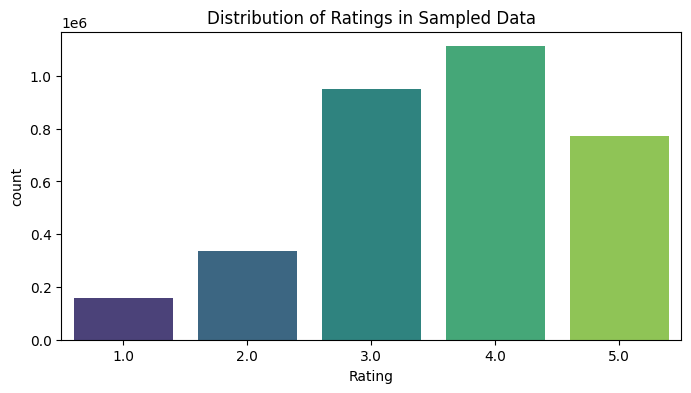

Total unique users: 16006
Total unique movies: 17631


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 'data' 변수 존재 여부 및 데이터 유무 확인
if 'data' in globals() and data is not None and not data.empty:
    plt.figure(figsize=(8, 4))
    sns.countplot(x='Rating', data=data, palette='viridis')
    plt.title('Distribution of Ratings in Sampled Data')
    plt.show()

    print(f"Total unique users: {data['Cust_Id'].nunique()}")
    print(f"Total unique movies: {data['Movie_Id'].nunique()}")
else:
    print("[!] 'data' 변수가 정의되지 않았거나 비어 있습니다.")
    print("1. 'Load data' 셀(ID: Eqxd5ZIz7e0o)을 찾아 실행 버튼을 눌러주세요.")
    print("2. 데이터 로드가 완료된 후 이 셀을 다시 실행하면 시각화 결과가 나타납니다.")

In [ ]:
import torch
from torch.utils.data import DataLoader

# 데이터셋 객체 생성 (전체 데이터에서 시퀀스 추출)
print("Creating NetflixDataset... (This may take a few minutes)")
dataset = NetflixDataset(data, seq_len=10)

# 학습용 데이터 로더 설정
data_loader = DataLoader(dataset, batch_size=512, shuffle=True)
print(f"DataLoader ready. Total sequences: {len(dataset)}")

In [ ]:
num_movies = data["Movie_Id"].max()
model = RecommendationNetwork(num_movies=num_movies, emb_size=100).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
import torch

def calculate_accuracy(y_pred: torch.Tensor, y_true: torch.Tensor) -> float:
    # 평점을 반올림하여 정확도 계산 (정수 평점 가정)
    y_pred_rounded = torch.round(y_pred).clamp(1, 5)
    correct_predictions = (y_pred_rounded == y_true).float().sum()
    accuracy = correct_predictions / y_true.shape[0]
    return accuracy.item()

def calculate_rmse(y_pred: torch.Tensor, y_true: torch.Tensor) -> float:
    # RMSE 계산 (연속형 평점 예측 품질 지표)
    mse = F.mse_loss(y_pred, y_true)
    return torch.sqrt(mse).item()

In [ ]:
# Ensure dependencies and model class are available
if 'RecommendationNetwork' not in globals():
    print("RecommendationNetwork class not found. Please ensure cell 'gdANR47UQSia' is executed.")

if 'model' not in globals() and 'RecommendationNetwork' in globals():
    print("Model not found. Initializing model...")
    num_movies = 17770 # Default based on Netflix dataset
    model = RecommendationNetwork(num_movies=num_movies, emb_size=100).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

if 'data_loader' in globals():
    loss_values: list[float] = []
    accuracy_values: list[float] = []
    rmse_values: list[float] = []
    num_epochs = 5

    for epoch in range(num_epochs):
        model.train()
        total_loss, total_accuracy, total_rmse = 0.0, 0.0, 0.0
        count_batches = 0

        pbar = tqdm(data_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        for movies, ratings in pbar:
            movies = movies.to(device)
            ratings = ratings.to(device)
            target = ratings[:, -1]

            optimizer.zero_grad()
            outputs = model(movies)

            loss = criterion(outputs, target)
            loss.backward()
            optimizer.step()

            acc = calculate_accuracy(outputs, target)
            rmse = calculate_rmse(outputs, target)

            total_loss += loss.item()
            total_accuracy += acc
            total_rmse += rmse
            count_batches += 1

            pbar.set_postfix({'Loss': f"{loss.item():.4f}", 'Acc': f"{acc:.4f}"})

        avg_loss = total_loss / count_batches
        avg_acc = total_accuracy / count_batches
        avg_rmse = total_rmse / count_batches

        loss_values.append(avg_loss)
        accuracy_values.append(avg_acc)
        rmse_values.append(avg_rmse)

        print(f"[Epoch {epoch+1}] Avg Loss: {avg_loss:.4f}, Avg Acc: {avg_acc:.4f}, Avg RMSE: {avg_rmse:.4f}")
else:
    print("[!] data_loader가 정의되지 않았습니다. 데이터 로드 및 전처리 셀을 먼저 실행해 주세요.")

Epoch 1/5: 100%|██████████| 6231/6231 [33:49<00:00,  3.07it/s, Loss=1.1308, Acc=0.3815]


[Epoch 1] Avg Loss: 1.0689, Avg Acc: 0.3591, Avg RMSE: 1.0327


Epoch 2/5: 100%|██████████| 6231/6231 [33:30<00:00,  3.10it/s, Loss=1.0455, Acc=0.3815]


[Epoch 2] Avg Loss: 1.0189, Avg Acc: 0.3707, Avg RMSE: 1.0089


Epoch 3/5:  68%|██████▊   | 4206/6231 [22:43<10:58,  3.08it/s, Loss=1.1489, Acc=0.3516]

In [ ]:
import matplotlib.pyplot as plt

# 학습 결과 시각화 (변수 존재 및 데이터 유무 확인)
def plot_training_results():
    if 'loss_values' in globals() and len(loss_values) > 0:
        epochs = range(1, len(loss_values) + 1)
        plt.figure(figsize=(12, 5))

        # Loss Plot
        plt.subplot(1, 2, 1)
        plt.plot(epochs, loss_values, marker='o', label="Loss", color="#4285f4")
        plt.title("Training Loss Over Epochs")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.grid(True)
        plt.legend()

        # Accuracy Plot
        if 'accuracy_values' in globals() and len(accuracy_values) > 0:
            plt.subplot(1, 2, 2)
            plt.plot(epochs, accuracy_values, marker='s', label="Accuracy", color="#00ab75")
            plt.title("Training Accuracy Over Epochs")
            plt.xlabel("Epochs")
            plt.ylabel("Accuracy")
            plt.grid(True)
            plt.legend()

        plt.tight_layout()
        plt.show()
    else:
        print("[!] 학습 결과 데이터가 없습니다. 훈련 셀(8xCeZM3WQWnZ)을 먼저 실행해 주세요.")

plot_training_results()

## Inference

In [ ]:
%%writefile model.py
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, emb_size: int, max_len: int = 5000):
        super(SinusoidalPositionalEncoding, self).__init__()
        # pos: [0 ... max_len-1]
        position = torch.arange(max_len).unsqueeze(1)
        # div_term: 각 차원별 주기를 달리하기 위한 분모
        div_term = torch.exp(torch.arange(0, emb_size, 2) * (-math.log(10000.0) / emb_size))

        # pos_embedding: (max_len, emb_size)
        pos_embedding = torch.zeros(max_len, emb_size)
        pos_embedding[:, 0::2] = torch.sin(position * div_term)
        pos_embedding[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pos_embedding', pos_embedding)  # 학습 X, 등록된 텐서

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch_size, seq_len, emb_size)
        seq_len = x.size(1)
        # pos_embedding 중 seq_len 길이에 해당하는 부분만 사용
        return x + self.pos_embedding[:seq_len, :]

class RecommendationNetwork(nn.Module):
    def __init__(
        self,
        num_movies: int,
        emb_size: int = 100,
        nhead: int = 4,
        num_layers: int = 2,
        dim_feedforward: int = 512,
        max_seq_len: int = 5000  # 가변 시퀀스 길이 지원을 위해 충분히 큰 값 설정
    ):
        super(RecommendationNetwork, self).__init__()

        self.movie_emb = nn.Embedding(num_movies + 1, emb_size)
        self.pos_encoder = SinusoidalPositionalEncoding(emb_size, max_len=max_seq_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_size,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(emb_size, 1)

    def forward(self, movies: torch.Tensor) -> torch.Tensor:
        """
        movies: (batch_size, seq_len)
        seq_len이 가변적이어도 positional encoding을 매번 해당 길이에 맞춰 계산 가능
        """
        batch_size, seq_len = movies.size()

        embedded = self.movie_emb(movies)  # (batch_size, seq_len, emb_size)
        pos_encoded = self.pos_encoder(embedded)  # (batch_size, seq_len, emb_size)

        transformer_out = self.transformer_encoder(pos_encoded)  # (batch_size, seq_len, emb_size)
        preds = self.fc(transformer_out[:, -1, :])  # (batch_size, 1)

        return preds.squeeze(1)  # (batch_size,)

In [ ]:
%%writefile handler.py
import logging
from ts.torch_handler.base_handler import BaseHandler
import torch
from model import RecommendationNetwork

logging.basicConfig(level=logging.INFO)

class NetflixRecommendation(BaseHandler):
    def initialize(self, context):
        properties = context.system_properties
        model_dir = properties.get("model_dir")
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.num_movies = 17770
        # 가변 길이를 지원하는 모델이므로 seq_len을 고정하지 않습니다.
        self.model = RecommendationNetwork(num_movies=self.num_movies, emb_size=100)
        model_path = model_dir + "/model.pth"
        self.model.load_state_dict(torch.load(model_path, map_location=self.device))
        self.model.to(self.device)
        self.model.eval()

    def preprocess(self, data):
        """
        data 예: [[{"movies": [m1, ..., mN]}], [{"movies": [...]}, ...]]
        """
        logging.info("preprocess input: %s", data)

        # 요청 구조 기록
        self.batch_structure = [len(batch) for batch in data]

        sequences = []
        for batch in data:
            for row in batch:
                movie_seq = row["movies"]
                # 가변 길이 시퀀스를 지원하므로, 길이 검사를 제거합니다.
                sequences.append(movie_seq)

        # 패딩 필요 여부에 따라 처리할 수 있습니다.
        # Transformer에 바로 넣으려면 패딩과 마스크 처리 필요.
        # 여기서는 단순히 텐서 변환(가장 긴 시퀀스에 맞춰 패딩 필요)
        # 예: padding 처리
        max_len = max(len(seq) for seq in sequences)
        padded_sequences = [seq + [0]*(max_len - len(seq)) for seq in sequences]

        movies_tensor = torch.tensor(padded_sequences, dtype=torch.long, device=self.device)
        self.max_len = max_len  # postprocessing할 때는 필요없지만, inference에서 사용할 수 있음

        return movies_tensor

    def inference(self, data):
        """
        data: (total_batch_size, max_seq_len) 텐서 (패딩된 형태)
        """
        logging.info("inference data shape: %s", data.shape)
        with torch.no_grad():
            outputs = self.model(data)  # (total_batch_size,) 형태
        return outputs.tolist()

    def postprocess(self, inference_output):
        """
        inference_output: flat list of predictions
        """
        logging.info("postprocess output: %s", inference_output)

        final_output = []
        idx = 0
        for size in self.batch_structure:
            batch_preds = inference_output[idx:idx+size]
            idx += size
            final_output.append(batch_preds)
        return final_output

In [ ]:
torch.save(model.state_dict(), "model.pth")

In [ ]:
# 가상의 Context 클래스 정의 (TorchServe context 모사)
class Context:
    def __init__(self):
        self.system_properties = {
            "model_dir": "."
        }


context = Context()

In [ ]:
!pip install torchserve torch-model-archiver

In [ ]:
from handler import NetflixRecommendation

# 핸들러 인스턴스화 및 초기화
netflix_recommendation = NetflixRecommendation()
netflix_recommendation.initialize(Context())

# 샘플 입력: seq_len=10 짜리 영화 시퀀스
sample_input = {"movies": [123, 456, 789, 100, 101, 102, 103, 104, 105, 106]}

# TorchServe 표준 입력 형태: [[sample_input]]
preprocessed = netflix_recommendation.preprocess([[sample_input]])
predicted_rating = netflix_recommendation.inference(preprocessed)
result = netflix_recommendation.postprocess(predicted_rating)

print(f"Predicted Rating: {result}")

## Register to Vertex AI

### Vertex AI 배포 심화 가이드
1. **Custom Container 이미지**: `serving_container_image_uri`는 PyTorch와 TorchServe가 설치된 이미지를 가리킵니다. Google Cloud의 Pre-built 이미지를 사용하거나, 특정 라이브러리가 필요한 경우 직접 빌드하여 Artifact Registry에 푸시한 이미지를 사용할 수 있습니다.
2. **리소스 할당**: `DEPLOY_COMPUTE` (`n1-standard-2`)와 `DEPLOY_ACCELERATOR` (`NVIDIA_TESLA_T4`) 설정은 모델의 추론 속도와 비용에 직결됩니다. 트래픽에 따라 `min_replica_count`를 조절하여 Auto-scaling을 설정할 수 있습니다.
3. **서빙 경로**: `serving_container_predict_route="/predictions/model"`은 TorchServe의 기본 예측 엔드포인트 규칙을 따릅니다. 핸들러에서 정의한 `preprocess`가 이 경로를 통해 들어오는 JSON 데이터를 처리하게 됩니다.

In [ ]:
!torch-model-archiver \
    --model-name model \
    --version 1.0 \
    --model-file model.py \
    --serialized-file model.pth \
    --handler handler.py \
    --export-path . \
    --force

In [ ]:
%%writefile config.properties
inference_address=http://0.0.0.0:9080
management_address=http://0.0.0.0:9081
metrics_address=http://0.0.0.0:9082
disable_system_metrics=true
number_of_netty_threads=32
job_queue_size=1000
model_store=/home/model-server/model-store

In [ ]:
# # for testing
# !torchserve \
#     --start \
#     --model-store ./ \
#     --models recommendation=model.mar \
#     --ts-config config.properties

# curl http://localhost:9080/ping

In [ ]:
from google.cloud import storage, aiplatform
from google.oauth2 import service_account

In [ ]:
# from google.colab import auth
# auth.authenticate_user()

In [ ]:
credentials = service_account.Credentials.from_service_account_file("credentials.json")

In [ ]:
PROJECT_ID = "gde-project-aicloud"                    # @param {type: "string"}
LOCATION = "asia-northeast3"                                       # @param {type: "string"}
BUCKET_NAME = "mlops-quicklab"   # @param {type: "string"}
MODEL_FILE_NAME = "model.mar"              # @param {type: "string"}

In [ ]:
storage_client = storage.Client(credentials=credentials)
bucket = storage_client.bucket(BUCKET_NAME)

In [ ]:
def upload_blob(source_file_name: str, destination_blob_name: str) -> None:
    blob = bucket.blob(destination_blob_name)
    blob.upload_from_filename(source_file_name)
    print(f"File {source_file_name} uploaded to {destination_blob_name}.")

In [ ]:
upload_blob("model.mar", f"models/{MODEL_FILE_NAME}")

In [ ]:
aiplatform.init(
    project=PROJECT_ID,
    location=LOCATION,
    credentials=credentials,
)

In [ ]:
model_path = f"gs://{BUCKET_NAME}/models"
registry_model = aiplatform.Model.upload(
    display_name="Netflix Recommender",
    artifact_uri=model_path,
    serving_container_image_uri="asia-northeast3-docker.pkg.dev/gde-project-aicloud/mlops-quicklab/trainer:1.0.3",
    is_default_version=True,
    version_aliases=["v1"],
    version_description="A netflix rating classification model",
    serving_container_predict_route="/predictions/model",
    serving_container_health_route="/ping",
)

In [ ]:
DEPLOY_COMPUTE = "n1-standard-2"
DEPLOY_ACCELERATOR = "NVIDIA_TESLA_T4"

In [ ]:
endpoint = aiplatform.Endpoint.create(
    display_name="netflix-recommendation",
    project=PROJECT_ID,
    location=LOCATION,
)

In [ ]:
deployment = registry_model.deploy(
    endpoint=endpoint,
    machine_type=DEPLOY_COMPUTE,
    min_replica_count=1,
    max_replica_count=1,
    accelerator_type=DEPLOY_ACCELERATOR,
    accelerator_count=1,
    traffic_percentage=100,
    sync=True,
)

In [ ]:
instances = [{"movies": [100, 101, 102, 103, 104, 105, 106, 107, 108, 400]}]
endpoint.predict(instances=[instances])

## Clean up

In [ ]:
# 클라우드 리소스 삭제
if 'endpoint' in globals():
    print("Cleaning up Vertex AI Endpoint...")
    endpoint.undeploy_all()
    endpoint.delete()
else:
    print("Endpoint variable not found. Skipping cloud resource deletion.")

# 로컬 임시 파일 정리
import os
for file in ["model.mar", "model.pth", "model.py", "handler.py", "config.properties", "credentials.json"]:
    if os.path.exists(file):
        os.remove(file)
        print(f"Removed temporary file: {file}")

print("Clean up completed.")

In [ ]:
registry_model.delete()